<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 7: The Exponential Function

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#power" style="color:black;">The Exponential Function and Its Power Series</a></li>
    <li><a href="#background_convergence" style="color:#1B5E20;"><strong>Background:</strong> Why the Exponential Series Converges</a></li>    
    <li><a href="#complex_exp" style="color:black;">The Complex Exponential Function</a></li>
    <li><a href="#euler" style="color:black;">Euler's Formula: From Growth to Rotation</a></li>
    <li><a href="#background_euler" style="color:#1B5E20;"><strong>Background:</strong> Euler's Identity and Mathematical Beauty</a></li>
    <li><a href="#differential" style="color:black;">The Exponential Function and Differential Equations</a></li>
    <li><a href="#roots" style="color:black;">Roots of Unity</a></li>
    <li><a href="#exercise_approx_exp" style="color:#006064;"><strong>Exercise 1:</strong> Comparing Approximations of the Exponential Function</a></li>
    <li><a href="#exercise_gaussian" style="color:#006064;"><strong>Exercise 2:</strong> Exploring the Gaussian Function</a></li>
    <li><a href="#exercise_spiral" style="color:#006064;"><strong>Exercise 3:</strong> Generating Complex Spirals</a></li>
</ul>

<a id="learn"></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
You may already know the <strong>exponential function</strong> from school as a model for growth and decay. A familiar example is money in a bank account that earns a fixed percentage of interest: each interest payment is based on the current balance, so the amount grows exponentially over time. In this unit, however, we take a broader view. We define the exponential function through its power series and extend its input from real numbers $x\in\mathbb{R}$ to complex numbers $z\in\mathbb{C}$. This extension reveals properties that are particularly important for the topics studied in this course. For real inputs, the exponential function describes changes in magnitude. For purely <strong>imaginary inputs</strong>, its values lie on the <strong>unit circle</strong>. Euler's formula connects these values directly to sine and cosine, allowing angles and rotations to be expressed through complex numbers. Complex exponentials therefore provide a natural language for oscillations and form the mathematical foundation of the Fourier transform and discrete Fourier transform studied in <a href="PCP_09_dft.html">Unit 9</a>.
</p>

<p style="color:#E65100;">
We introduce the exponential function using its <strong>power series</strong> and study its exponentiation identity, which transforms the addition of two input values into the multiplication of their exponential values. We then interpret the exponential function from the perspective of differential equations. Finally, we use complex exponentials to construct roots of unity, which will later become the building blocks of the discrete Fourier transform. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Approximate the exponential function using partial sums of its power series and the compounding limit.</li>
<li>Evaluate and interpret the exponential function for real and complex arguments.</li>
<li>Use the exponentiation identity and Euler's formula to relate complex exponentials to sine and cosine.</li>
<li>Explain why the exponential function satisfies $f'(x)=f(x)$ and explore its numerical approximation using Euler's method.</li>
<li>Construct and visualize <strong>roots of unity</strong> in the complex plane.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_approx_exp">Exercise 1</a>: Implement and compare two approximations of the exponential function.</li>
<li><a href="#exercise_gaussian">Exercise 2</a>: Compute and visualize Gaussian functions with different parameters.</li>
<li><a href="#exercise_spiral">Exercise 3</a>: Generate complex spirals by combining changing radii and angles.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
The central idea is a remarkable change of perspective: extending the exponential function from $\mathbb{R}$ to $\mathbb{C}$ transforms a familiar function for growth and decay into a powerful tool for describing rotation and oscillation.
</p>

</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import matplotlib.pyplot as plt

# --- Custom utilities (Unit 7) ---
from libpcp.unit07 import (
    exercise_approx_exp,
    exercise_gaussian,
    exercise_spiral,
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="power"></a>

## The Exponential Function and Its Power Series

The **real exponential function** $\exp:\mathbb{R}\to\mathbb{R}_{>0}$ appears throughout mathematics and can be characterized in several equivalent ways. One intuitive approach comes from compound interest. In the late seventeenth century, [Jacob Bernoulli](https://en.wikipedia.org/wiki/Jacob_Bernoulli) investigated what happens when interest is added to an account increasingly often.

Suppose an initial amount of $1$ earns interest at an annual rate $x$, where $x=0.05$, for example, corresponds to $5\%$. With monthly compounding, the current balance is multiplied by $1+x/12$ twelve times. The balance after one year is therefore

$$
\left(1+\frac{x}{12}\right)^{12}.
$$

With daily compounding, the annual rate is divided among $365$ periods, resulting in

$$
\left(1+\frac{x}{365}\right)^{365}.
$$

More generally, dividing the interest among $n$ equally spaced periods gives the balance

$$
\left(1+\frac{x}{n}\right)^n.
$$

As $n$ increases, increasingly small portions of interest are added increasingly often. Letting $n$ tend to infinity leads to **continuous compounding** and the limit

$$
\exp(x):=\lim_{n\to\infty}
\left(1+\frac{x}{n}\right)^n.
$$

For $x=1$, this limit gives **Euler's number**

$$
e:=\exp(1)\approx2.71828.
$$

[Leonhard Euler](https://en.wikipedia.org/wiki/Leonhard_Euler) used the symbol $e$ systematically and developed many fundamental properties of the exponential function. The function is therefore also written as $\exp(x)=e^x$.

An equivalent representation is given by the **power series**

$$
\exp(x)=\sum_{n=0}^{\infty}\frac{x^n}{n!}
=1+x+\frac{x^2}{2!}+\frac{x^3}{3!}+\cdots,
\qquad x\in\mathbb{R},
$$

where $0!:=1$ and $n!:=1\cdot2\cdots n$ for every positive integer $n$. The first $N+1$ terms form the **partial sum**

$$
S_N(x):=\sum_{n=0}^{N}\frac{x^n}{n!}.
$$

Neither the existence of the compounding limit nor the convergence of the infinite series is automatic. One must also show that both constructions produce the same function. We use these standard mathematical results without proof. The convergence of the exponential series will be examined more closely in the background box on [why the exponential series converges](#background_convergence).

A computer cannot add infinitely many terms. Instead, it uses a finite partial sum $S_N(x)$ to approximate $\exp(x)$. The approximation generally improves as more terms are included, although the required value of $N$ depends on the input and the desired accuracy. We will investigate this relationship in <a href="#exercise_approx_exp">Exercise 1</a>.

NumPy provides the function [`np.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) for evaluating the exponential function at individual values or complete arrays:

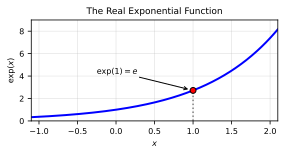

In [2]:
x = np.linspace(-1.1, 2.1, 321)
y = np.exp(x)
e = np.exp(1)

plt.figure(figsize=(4, 2.2), layout='tight')
plt.plot(x, y, color='blue', linewidth=2)
plt.plot([1, 1], [0, e], color='gray', linestyle=':')
plt.scatter(1, e, color='red', edgecolor='black', s=35, zorder=3)
plt.annotate(r'$\exp(1)=e$', xy=(1, e), xytext=(-0.25, 4.2),
             arrowprops=dict(arrowstyle='->', shrinkA=0, shrinkB=-5, color='black'))

plt.xlim(-1.1, 2.1)
plt.ylim(0, 9)
plt.xlabel('$x$')
plt.ylabel(r'$\exp(x)$')
plt.title('The Real Exponential Function')
plt.grid(alpha=0.3);

The graph shows several characteristic properties of the real exponential function. Its values are always positive, it passes through the point $(0,1)$, and the highlighted point satisfies $\exp(1)=e$. As $x$ increases, the function grows increasingly rapidly. As $x$ tends to $-\infty$, the function values approach zero without ever becoming zero.

The bank-account example motivates the exponential function only for real inputs: an interest rate is a real quantity, and a complex interest rate has no natural interpretation in this example. The power series, however, is constructed using addition, multiplication, integer powers, and division by the real numbers $n!$. These operations are also defined for complex numbers. Replacing the real input $x$ by a complex input $z$ therefore produces a meaningful series with complex-valued terms. To use this series as a definition, we must additionally know that it converges for every $z\in\mathbb{C}$. This leads to the complex exponential function introduced in the next section.

<a id="background_convergence"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Why the Exponential Series Converges
</h2>

<p style="color:#1B5E20;">
You may already know one of the most famous infinite sums:
$$
1+\frac12+\frac14+\frac18+\cdots=2.
$$
Starting with $1$, we repeatedly add half as much as before. The partial sums approach $2$ without exceeding it. This is the case $p=1/2$ of the <strong>geometric series</strong> $\sum_{n=0}^{\infty}p^n=1/(1-p)$, which converges for $|p|<1$. Not every infinite sum behaves so well. The <strong>harmonic series</strong> $\sum_{n=1}^{\infty}1/n=1+1/2+1/3+\cdots$ diverges to infinity even though its individual terms approach zero. The fact that the terms approach zero is therefore necessary for convergence, but it is not sufficient.
</p>

<p style="color:#1B5E20;">
In general, the infinite series $\sum_{n=0}^{\infty}a_n$ is defined through its partial sums $S_N:=\sum_{n=0}^{N}a_n$. It <strong>converges</strong> if $S_N$ approaches a finite limit as $N\to\infty$; this limit is then called the value of the series. If no finite limit exists, the series diverges. A stronger property is <a href="https://en.wikipedia.org/wiki/Absolute_convergence"><strong>absolute convergence</strong></a>: the series $\sum_{n=0}^{\infty}a_n$ converges absolutely if $\sum_{n=0}^{\infty}|a_n|$ converges. Taking absolute values removes signs and, for complex numbers, directions. Convergence then cannot depend on cancellation between terms. Absolute convergence always implies convergence, but the reverse implication does not always hold.
</p>

<p style="color:#1B5E20;">
We now apply these ideas to the complex exponential series
$$
\exp(z)=\sum_{n=0}^{\infty}\frac{z^n}{n!}
=1+z+\frac{z^2}{2!}+\frac{z^3}{3!}+\cdots,
\qquad z\in\mathbb{C}.
$$
For $z=0$, all terms except the first vanish, and the series has the value $1$. Now fix any $z\neq0$. The ratio of the magnitudes of two consecutive terms is
$$
\frac{|z|^{n+1}/(n+1)!}{|z|^n/n!}
=\frac{|z|}{n+1}.
$$
</p>

<p style="color:#1B5E20; margin-bottom:0;">
Although $|z|$ may be large, it remains fixed while $n+1$ grows without bound. We can therefore choose an index $N$ such that $|z|/(n+1)\leq1/2$ for every $n\geq N$. From that point onward, each term is at most half as large as the preceding one. If $b_N:=|z|^N/N!$, the remaining magnitudes satisfy
$$
b_N+b_{N+1}+b_{N+2}+\cdots
\leq
b_N\left(1+\frac12+\frac1{2^2}+\cdots\right)
=2b_N.
$$
The tail is therefore bounded by a convergent geometric series. The finitely many terms before $N$ cannot cause divergence, so $\sum_{n=0}^{\infty}|z|^n/n!$ has a finite value. Thus, the exponential power series converges absolutely for every $z\in\mathbb{C}$. No matter how large the fixed modulus $|z|$ is, one only needs to go far enough along the series for the factorial to win the race against the power $|z|^n$.
</p>

</div>

## The Complex Exponential Function

The preceding [background box](#background_convergence) showed that the exponential power series converges absolutely for every complex input. We can therefore use the same series to define the **complex exponential function** $\exp:\mathbb{C}\to\mathbb{C}$:

$$
\exp(z):=\sum_{n=0}^{\infty}\frac{z^n}{n!}
=1+z+\frac{z^2}{2!}+\frac{z^3}{3!}+\cdots,
\qquad z\in\mathbb{C}.
$$

When $z$ is real, this series is identical to the real power series introduced above. The complex exponential function is therefore an **extension** of the real exponential function: it preserves all familiar values on the real axis while additionally assigning values to inputs with nonzero imaginary parts. NumPy uses the same function [`np.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) for real and complex inputs:

In [3]:
z = 1 + 0.5j
w = np.exp(z)

print('z:                   ', z)
print('exp(z):              ', w)
print('Real part of exp(z): ', np.real(w))
print('Imaginary part:      ', np.imag(w))
print('Modulus of exp(z):   ', np.abs(w))

z:                    (1+0.5j)
exp(z):               (2.3855167309591354+1.3032137296869954j)
Real part of exp(z):  2.3855167309591354
Imaginary part:       1.3032137296869954
Modulus of exp(z):    2.7182818284590446


Unlike the real exponential function, which produces positive real values, the complex exponential function maps a complex input $z\in\mathbb{C}$ to a complex output $\exp(z)\in\mathbb{C}$. Writing $z=x+iy$ identifies the input with the point $(x,y)$, where $x=\operatorname{Re}(z)$ and $y=\operatorname{Im}(z)$. Similarly, the output is described by its real part and imaginary part:

$$
\exp(z)=\operatorname{Re}(\exp(z))
+i\operatorname{Im}(\exp(z))
$$

The following figure evaluates $\exp(z)$ on a rectangular grid of input points $(x,y)$. In all three panels, the axes represent $\operatorname{Re}(z)$ and $\operatorname{Im}(z)$. The colors show different properties of the corresponding output: $\operatorname{Re}(\exp(z))$, $\operatorname{Im}(\exp(z))$, and $|\exp(z)|$, respectively:

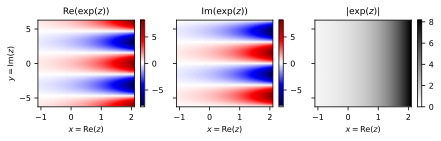

In [4]:
x = np.linspace(-1.1, 2.1, 81)
y = np.linspace(-2 * np.pi, 2 * np.pi, 161)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
E = np.exp(Z)
extent = [x[0], x[-1], y[0], y[-1]]
limit = np.exp(x[-1])

plots = [
    (E.real, r'$\operatorname{Re}(\exp(z))$', 'seismic', -limit, limit),
    (E.imag, r'$\operatorname{Im}(\exp(z))$', 'seismic', -limit, limit),
    (np.abs(E), r'$|\exp(z)|$', 'gray_r', 0, limit),
]

fig, axes = plt.subplots(1, 3, figsize=(6.2, 2), layout='tight', sharey=True)

for ax, (values, title, cmap, vmin, vmax) in zip(axes, plots):
    image = ax.imshow(
        values, cmap=cmap, origin='lower', aspect='auto',
        extent=extent, vmin=vmin, vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel(r'$x=\operatorname{Re}(z)$')
    fig.colorbar(image, ax=ax)

axes[0].set_ylabel(r'$y=\operatorname{Im}(z)$');

Several patterns are visible in the figure. In the first two panels, the real and imaginary parts of $\exp(z)$ oscillate as the imaginary coordinate $y$ changes. These oscillations repeat after $2\pi$, while their amplitudes increase as the real coordinate $x$ increases. In the third panel, the modulus changes only in the horizontal direction and remains constant along every vertical line. It therefore appears to depend on $x=\operatorname{Re}(z)$ but not on $y=\operatorname{Im}(z)$. At this stage, these are observations from a numerical visualization. The next section explains them mathematically. Euler's formula will show that the real part $x$ controls the modulus of $\exp(x+iy)$, while the imaginary part $y$ controls its angle. The complex exponential function thereby connects two seemingly different behaviors: exponential growth and rotation.

<a id="euler"></a>
## Euler's Formula: From Growth to Rotation

Starting from the power-series definition, one can prove two famous formulas that explain many properties of the exponential function. The first is the **exponentiation identity**

$$
\exp(z_1+z_2)=\exp(z_1)\exp(z_2),
\qquad z_1,z_2\in\mathbb{C}.
$$

Thus, adding inputs corresponds to multiplying their exponential values. For a positive integer $n$, repeated application gives

$$
\exp(n)
=\exp(\underbrace{1+\cdots+1}_{n\text{ terms}})
=\underbrace{\exp(1)\cdots\exp(1)}_{n\text{ factors}}
=e^n.
$$

This illustrates exponential growth for real inputs: increasing the input by $1$ multiplies the output by the constant factor $e$. For a complex input $z=x+iy$, the same identity gives $\exp(x+iy)=\exp(x)\exp(iy)$. The positive real factor $\exp(x)$ controls the magnitude, while the meaning of $\exp(iy)$ is revealed by **Euler’s formula**:

$$
\exp(iy)=\cos(y)+i\sin(y),
\qquad y\in\mathbb{R}.
$$

Euler’s formula can be derived from the power-series definitions. Substituting $iy$ into the exponential series and using $i^2=-1$ separates the result into real and imaginary parts. These are precisely the familiar cosine and sine functions: on the unit circle, $\cos(y)$ is the horizontal coordinate of the point at angle $y$, while $\sin(y)$ is its vertical coordinate. Euler’s formula combines both coordinates into the single complex number $\cos(y)+i\sin(y)$.

Since $\cos^2(y)+\sin^2(y)=1$, the number $\exp(iy)$ has modulus $1$. As $y$ increases, it moves counterclockwise around the unit circle. Combining Euler’s formula with the exponentiation identity gives

$$
\exp(x+iy)
=\exp(x)\bigl(\cos(y)+i\sin(y)\bigr).
$$

This explains the preceding visualization: the real part $x$ of the input determines the modulus $|\exp(x+iy)|=\exp(x)$, while the imaginary part $y$ determines the angle. In particular,

$$
\operatorname{Re}(\exp(x+iy))=\exp(x)\cos(y),
\qquad
\operatorname{Im}(\exp(x+iy))=\exp(x)\sin(y).
$$

The complex exponential therefore combines **growth through the real part of its input** with **rotation through the imaginary part**. To examine the rotational component separately, consider the purely imaginary input $i\gamma$, where $\gamma\in\mathbb{R}$ is interpreted as an angle measured in radians. As $\gamma$ increases from $0$ to $2\pi$, the value $\exp(i\gamma)$ completes one counterclockwise turn around the unit circle. The following figure shows this motion in polar coordinates and, in the two panels on the right, the corresponding real and imaginary parts as functions of $\gamma$. Matching colors identify the same angle in all three panels:

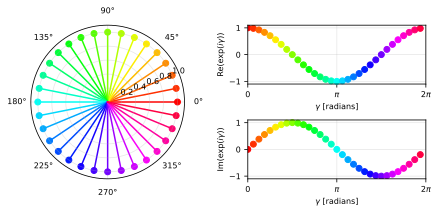

In [5]:
cmap = plt.get_cmap('hsv')  # hsv is nice because it defines a circular colormap
N = 32

fig = plt.figure(figsize=(6.2, 3), layout='tight')
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[:, 0], projection='polar')
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1])

ax1.set_ylim(0, 1.1)
ax1.yaxis.set_zorder(5)
ax1.grid(alpha=0.3)

for i in range(N):
    gamma = 2 * np.pi * i / N
    c = np.exp(1j * gamma)
    color = cmap(i / N)
    ax1.plot([gamma, gamma], [0, np.abs(c)], color=color)
    ax1.plot(gamma, np.abs(c), 'o', color=color)
    ax2.plot(gamma, np.real(c), 'o', color=color)
    ax3.plot(gamma, np.imag(c), 'o', color=color)

for ax in [ax2, ax3]:
    ax.set(xlim=(0, 2 * np.pi), xlabel=r'$\gamma$ [radians]')
    ax.set_xticks([0, np.pi, 2 * np.pi],
                  ['0', r'$\pi$', r'$2\pi$'])
    ax.grid(alpha=0.3)

ax2.set_ylabel(r'$\operatorname{Re}(\exp(i\gamma))$')
ax3.set_ylabel(r'$\operatorname{Im}(\exp(i\gamma))$');

We have seen from Euler's formula that $\exp(i\gamma)$ lies on the unit circle for every $\gamma\in\mathbb{R}$. The number $\gamma$ specifies its angle in radians, while $|\exp(i\gamma)|=1$. Because the values repeat after a complete turn, it suffices to consider $\gamma\in[0,2\pi)$. The exponentiation identity and Euler’s formula imply

$$
\begin{aligned}
\exp(i\gamma) &= \exp\bigl(i(\gamma+2\pi)\bigr),\\
|\exp(i\gamma)| &= 1,\\
\overline{\exp(i\gamma)} &= \exp(-i\gamma),\\
\exp\bigl(i(\gamma_1+\gamma_2)\bigr)
&= \exp(i\gamma_1)\exp(i\gamma_2).
\end{aligned}
$$

Substituting Euler's formula into the final identity and comparing real and imaginary parts gives the familiar angle-addition formulas

$$
\begin{aligned}
\cos(\gamma_1+\gamma_2)
&=\cos(\gamma_1)\cos(\gamma_2)-\sin(\gamma_1)\sin(\gamma_2),\\
\sin(\gamma_1+\gamma_2)
&=\cos(\gamma_1)\sin(\gamma_2)+\cos(\gamma_2)\sin(\gamma_1).
\end{aligned}
$$

<a id="background_euler"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Euler's Identity and Mathematical Beauty
</h2>

<p style="color:#1B5E20;">
Setting the angle to $\pi$ in Euler's formula describes a half-turn around the unit circle: $\exp(i\pi)=\cos(\pi)+i\sin(\pi)=-1$. Since $\exp(z)=e^z$, adding $1$ gives the celebrated <a href="https://en.wikipedia.org/wiki/Euler%27s_identity"><strong>Euler's identity</strong></a>:
$$
e^{i\pi}+1=0.
$$
What looks mysterious as an algebraic equation has a simple geometric meaning: a half-turn carries $1$ to $-1$, and adding $1$ brings the result to zero. Euler's identity is often described as one of the most <a href="https://en.wikipedia.org/wiki/Mathematical_beauty"><strong>beautiful</strong></a> formulas in mathematics. Mathematical beauty does not refer mainly to visual appearance. It describes a combination of <strong>simplicity</strong>, <strong>surprise</strong>, and <strong>explanatory power</strong>: a short statement reveals a deep connection between ideas that initially appear unrelated. As discussed in the <a href="https://en.wikipedia.org/wiki/Euler%27s_identity">Wikipedia article on Euler's identity</a>, the formula contains <strong>three fundamental arithmetic operations</strong>, each appearing exactly once: multiplication in $i\pi$, exponentiation in $e^{i\pi}$, and addition in $e^{i\pi}+1$. It also connects <strong>five fundamental constants</strong>:
</p>

<ul style="color:#1B5E20;">
<li>$0$, the additive identity;</li>
<li>$1$, the multiplicative identity;</li>
<li>$\pi$, the fundamental circle constant;</li>
<li>$e$, Euler's number and the base of the exponential function;</li>
<li>$i$, the imaginary unit satisfying $i^2=-1$.</li>
</ul>

<p style="color:#1B5E20; margin-bottom:0;">
The importance of the identity lies in the broader relationship it represents. Complex exponentials connect growth, rotation, sine, and cosine and provide a natural language for oscillations, waves, roots of unity, and Fourier analysis. <strong>A half-turn, five constants, and three operations: Euler’s identity says an astonishing amount in a single line.</strong>
</p>

</div>

<a id="differential"></a>

## The Exponential Function and Differential Equations

The power series defines the exponential function, while Euler's formula connects it to rotations and oscillations. There is another remarkable perspective: **the derivative of the exponential function is the exponential function itself**. Power series may be differentiated term by term inside their interval of convergence. Since the exponential series converges everywhere, we obtain

$$
\frac{\mathrm{d}}{\mathrm{d}x}\exp(x)
=\frac{\mathrm{d}}{\mathrm{d}x}\sum_{n=0}^{\infty}\frac{x^n}{n!}
=\sum_{n=1}^{\infty}\frac{n x^{n-1}}{n!}
=\sum_{n=1}^{\infty}\frac{x^{n-1}}{(n-1)!}
=\exp(x).
$$

The reason is hidden in the factorial: differentiating $x^n$ produces the factor $n$, which cancels the same factor contained in $n!$. After shifting the index, the original series reappears. Differentiation changes most functions, but the exponential function comes back looking exactly the same. Equivalently, $\exp(x)$ solves the **initial-value problem**

$$
f'(x)=f(x),
\qquad
f(0)=1.
$$

An initial-value problem asks for a function that satisfies both a differential equation and a specified starting value. Here, the equation $f'(x)=f(x)$ requires the rate of change to equal the current function value, while $f(0)=1$ fixes the value from which the function begins. Together, these conditions uniquely determine $f(x)=\exp(x)$. More generally, the initial-value problem $f'(x)=\lambda f(x)$ with $f(0)=c$ has the solution $f(x)=c\exp(\lambda x)$. Positive real values of $\lambda$ produce growth, negative real values produce decay, and a purely imaginary value $\lambda=i\omega$ produces rotation. For $c=1$, Euler's formula gives $f(x)=\exp(i\omega x)=\cos(\omega x)+i\sin(\omega x)$, whose real and imaginary parts oscillate as cosine and sine.

Differential equations are not a main topic of this course, so we take only a short numerical detour. For a small step $\Delta x$, the derivative can be approximated by

$$
f'(x)\approx\frac{f(x+\Delta x)-f(x)}{\Delta x}.
$$

Solving this approximation for the next function value and substituting $f'(x)=f(x)$ leads to <a href="https://en.wikipedia.org/wiki/Euler_method"><strong>Euler's method</strong></a>. Let $x_n:=n\Delta x$ denote the grid points and let $f_n$ approximate $f(x_n)$. The method advances from one grid point to the next using the current value as an estimate of the local rate of change:

$$
f_{n+1}:=f_n+\Delta x\,f_n.
$$

Starting from $f_0=1$, this rule generates an approximation one step at a time. A smaller step usually gives a better result but requires more steps. After $N$ steps of length $\Delta x=x/N$, it gives

$$
f_N=\left(1+\frac{x}{N}\right)^N.
$$

This is precisely the expression encountered in continuous compounding. We have arrived at the same exponential function by a different route: what began as interest added repeatedly now appears as a differential equation followed numerically step by step. The following implementation illustrates this idea by comparing Euler’s approximation with `np.exp()` for two step sizes. The left column uses a linear vertical axis to show the overall growth, while the logarithmic scale in the right column makes multiplicative differences between the curves easier to recognize. Comparing the two rows shows how reducing the step size improves the approximation:

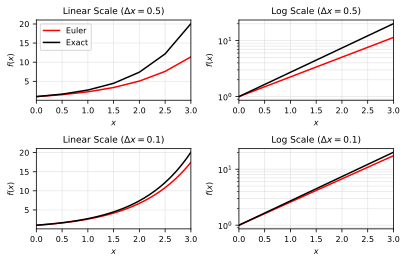

In [6]:
def exp_approx_Euler(x_min=0, x_max=2, x_delta=0.01, f_0=1):
    """Approximate f'=f using Euler's method."""
    x = np.arange(x_min, x_max + x_delta / 2, x_delta)
    f = np.zeros(len(x))
    f[0] = f_0

    for n in range(1, len(x)):
        f[n] = f[n - 1] + x_delta * f[n - 1]

    return f, x


x_max = 3
plots = [
    (0.5, 'linear'), (0.5, 'log'),
    (0.1, 'linear'), (0.1, 'log'),
]

fig, axes = plt.subplots(2, 2, figsize=(5.7, 3.7), layout='tight')

for ax, (x_delta, scale) in zip(axes.flat, plots):
    f, x = exp_approx_Euler(x_max=x_max, x_delta=x_delta)
    ax.plot(x, f, color='red', label='Euler')
    ax.plot(x, np.exp(x), color='black', label='Exact')
    ax.set_yscale(scale)
    ax.set_xlim(0, x_max)
    ax.set_title(
        rf'{scale.capitalize()} Scale ($\Delta x={x_delta}$)'
    )
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f(x)$')
    ax.grid(which='both', alpha=0.3)

axes[0, 0].legend();

<a id="roots"></a>
## Roots of Unity

In <a href="PCP_06_complex.html#background_polynomials">Unit 6</a>, we encountered the roots of polynomial equations. The complex exponential function now lets us revisit this topic geometrically. We ask a simple question: Which complex numbers become $1$ when raised to the $N^\mathrm{th}$ power? In mathematical terms, we seek the solutions of

$$
z^N=1,
$$

or equivalently $z^N-1=0$. These solutions are called the **$N^\mathrm{th}$ roots of unity**, where the term unity denotes the number $1$. Euler's formula gives $\exp(2\pi i)=1$ because an angle of $2\pi$ describes one complete turn around the unit circle. Imagine dividing the full circle into $N$ equal angular steps. One such step is represented by

$$
\rho_N:=\exp\left(\frac{2\pi i}{N}\right),
$$

which has modulus $1$ and angle $2\pi/N$. Multiplying by $\rho_N$ performs one rotation step. After $N$ steps, we have completed a full turn and returned to $1$:

$$
\rho_N^N
=\exp(2\pi i)
=1.
$$

Thus, $\rho_N$ is one solution of $z^N=1$. Taking its successive powers moves around the unit circle one step at a time. Using the exponentiation identity gives

$$
\rho_N^k
=\exp\left(\frac{2\pi i k}{N}\right),
\qquad k=0,\ldots,N-1,
$$

and every one of these values satisfies

$$
\left(\rho_N^k\right)^N
=\exp(2\pi i k)
=1.
$$

The values $1,\rho_N,\rho_N^2,\ldots,\rho_N^{N-1}$ are distinct and provide all $N$ roots of the polynomial $z^N-1$. In general, an $N^\mathrm{th}$ root of unity $c\in\mathbb{C}$ is called primitive if the smallest positive integer $m$ satisfying $c^m=1$ is $m=N$. Equivalently, the powers $1,c,c^2,\ldots,c^{N-1}$ are all distinct and provide all $N^\mathrm{th}$ roots of unity. The number $\rho_N$ is therefore primitive, but it is not necessarily the only primitive $N^\mathrm{th}$ root of unity.

The roots form a remarkably orderly geometric pattern. Every root has modulus $1$, and neighboring roots differ in angle by $2\pi/N$. They are therefore equally spaced around the unit circle and form the vertices of a regular $N$-sided polygon. What begins as a polynomial equation becomes a perfectly symmetric picture. The following visualization shows this structure for several values of $N$, with all primitive roots highlighted in red:

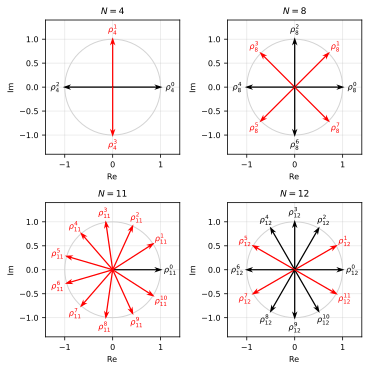

In [7]:
def plot_vector(c, ax, color='black', start=0,
                linestyle='-', linewidth=1.2):
    """Plot a complex number as a vector."""
    return ax.arrow(
        np.real(start), np.imag(start), np.real(c), np.imag(c),
        color=color, linestyle=linestyle, linewidth=linewidth,
        head_width=0.06, overhang=0.3,
        length_includes_head=True, zorder=3,
    )


def plot_roots_unity(N, ax):
    """Plot the N-th roots of unity."""
    rho = np.exp(2j * np.pi / N)
    ax.add_artist(plt.Circle((0, 0), 1, color='lightgray', fill=False, zorder=1))
    ax.set(
        xlim=(-1.4, 1.4), ylim=(-1.4, 1.4), aspect='equal',
        xlabel=r'$\operatorname{Re}$',
        ylabel=r'$\operatorname{Im}$', title=rf'$N={N}$',
    )
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)

    for k in range(N):
        root = rho**k
        color = 'red' if np.gcd(k, N) == 1 else 'black'
        plot_vector(root, ax, color=color)
        ax.text(
            1.2 * root.real, 1.2 * root.imag,
            rf'$\rho_{{{N}}}^{{{k}}}$',
            color=color, fontsize=8, ha='center', va='center',
        )


fig, axes = plt.subplots(2, 2, figsize=(5.2, 5.2), layout='tight')

for ax, N in zip(axes.flat, [4, 8, 11, 12]):
    plot_roots_unity(N, ax)

The colors reveal an additional number-theoretic pattern. One can show from the successive powers of $\rho_N^k$ that this root is primitive precisely when $k$ and $N$ have no common positive divisor other than $1$; such numbers are called **coprime**. Since $11$ is prime, every $k\in{1,\ldots,10}$ is coprime to $11$, so every root except $\rho_{11}^0=1$ is primitive. For the composite values $N=4$, $8$, and $12$, only roots whose exponents are coprime to $N$ are primitive and therefore shown in red.

This geometric structure is not merely decorative. Roots of unity will play a central role in the <a href="PCP_09_dft.html#dftmatrix">discrete Fourier transform (DFT) matrix</a>. As we will see, its entries are powers of the conjugate root

$$
\sigma_N:=\overline{\rho_N}
=\exp\left(-\frac{2\pi i}{N}\right),
$$

which represents a clockwise angular step of $2\pi/N$. Every entry of the DFT matrix has the form $\sigma_N^{kn}=\exp(-2\pi i kn/N)$. The matrix is therefore built from regularly sampled complex rotations. The nested structure of roots of unity is also important for the fast Fourier transform. When $N$ is even, every second $N^\mathrm{th}$ root is an $(N/2)^\mathrm{th}$ root:

$$
\rho_N^{2k}=\rho_{N/2}^k.
$$

This relationship makes it possible to separate a transform of length $N$ recursively into smaller transforms. Roots of unity therefore connect three central themes: **polynomial equations, rotations in the complex plane, and the efficient computation of Fourier transforms**.

<a id="exercise_approx_exp"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 1: Comparing Approximations of the Exponential Function</strong>

<p style="color:#006064;">
The exponential function was introduced through both its power series and the limit associated with continuous compounding. In this exercise, you will implement finite versions of these representations and compare their approximation quality.
</p>

<ul style="color:#006064;">
<li><strong>Power-series approximation:</strong> Implement a function <code>exp_power_series(z, N)</code> that returns
$$
S_N(z):=\sum_{n=0}^{N}\frac{z^n}{n!}.
$$
The partial sum contains $N+1$ terms and can be used for real or complex inputs $z$.</li>

<li><strong>Compounding approximation:</strong> Implement a function <code>exp_limit_compound(z, N)</code> that returns
$$
C_N(z):=\left(1+\frac{z}{N}\right)^N,
\qquad N\geq1.
$$</li>

<li><strong>Test the functions:</strong> Compare both approximations with <code>np.exp(z)</code> for $z\in\{1,-1,i\pi,1+i\}$, using, for example, $N=10$ and $N=100$.</li>

<li><strong>Visualize the errors:</strong> Fix $z=1+i$ and compute both approximations for $N=1,\ldots,25$. Display the absolute errors
$$
|S_N(z)-\exp(z)|
\qquad\text{and}\qquad
|C_N(z)-\exp(z)|
$$
in two subplots, first using linear axes and then using a logarithmic vertical axis. Describe what each representation reveals and which approximation approaches <code>np.exp(z)</code> more rapidly.</li>
</ul>

</div>


In [8]:
# Your Solution


z = 1, np.exp(z) = 2.71828183
N =  10: series = 2.71828180, compound = 2.59374246
N = 100: series = 2.71828183, compound = 2.70481383

z = -1, np.exp(z) = 0.36787944
N =  10: series = 0.36787946, compound = 0.34867844
N = 100: series = 0.36787944, compound = 0.36603234

z = 3.141592653589793j, np.exp(z) = -1.00000000+0.00000000j
N =  10: series = -1.00182910+0.00692527j, compound = -1.59336233+0.15606363j
N = 100: series = -1.00000000+0.00000000j, compound = -1.05055979+0.00108516j

z = (1+1j), np.exp(z) = 1.46869394+2.28735529j
N =  10: series = 1.46869489+2.28735450j, compound = 1.66602336+2.12814416j
N = 100: series = 1.46869394+2.28735529j, compound = 1.49124425+2.27250439j


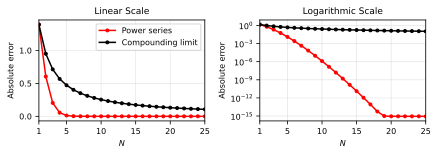


For sufficiently large N, a displayed error may stop decreasing because
floating-point precision has been reached. Such a plateau reflects a
limitation of the numerical computation rather than a failure of the
underlying mathematical approximation.


In [9]:
exercise_approx_exp()

<a id="exercise_gaussian"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 2: Exploring the Gaussian Function</strong>

<p style="color:#006064;">
So far, we have encountered the exponential function in descriptions of growth, decay, and complex rotation. The <a href="https://en.wikipedia.org/wiki/Gaussian_function"><strong>Gaussian function</strong></a> provides another important application. Its exponent contains the negative squared distance from a center $\mu$, causing the function to decrease rapidly and symmetrically as $x$ moves away from this center. The result is the familiar bell-shaped curve. Gaussian functions occur as probability densities in statistics and as localized pulses, smoothing kernels, and window functions in signal processing. They also have a special role in <a href="PCP_09_dft.html">Fourier analysis</a>, since the Fourier transform of a Gaussian is again a Gaussian. For a mean $\mu\in\mathbb{R}$ and a standard deviation $\sigma>0$, the Gaussian function is defined by
$$
g(x):=\frac{1}{\sigma\sqrt{2\pi}}
\exp\left(-\frac{1}{2}
\left(\frac{x-\mu}{\sigma}\right)^2\right),
\qquad x\in\mathbb{R}.
$$
The parameter $\mu$ determines the center of the function, while $\sigma$ controls its width. In statistics, $g$ is the probability density of a normally distributed random variable with mean $\mu$ and variance $\sigma^2$. The factor $1/(\sigma\sqrt{2\pi})$ normalizes the total area under the graph to $1$.
</p>

<ul style="color:#006064;">
<li><strong>Implement the function:</strong> Write a function <code>compute_gaussian_1D(x, mu, sigma)</code> that evaluates $g$ pointwise for every entry of a NumPy array <code>x</code>. Use <code>np.exp()</code> and return an array with the same shape as <code>x</code>.</li>

<li><strong>Vary the center:</strong> Create an array covering $[-5,5]$ and plot the Gaussian functions for $\mu\in\{-2,0,2\}$ with $\sigma=1$. Describe how changing $\mu$ affects the position and shape of the graph.</li>

<li><strong>Vary the width:</strong> Plot the Gaussian functions for $\sigma\in\{0.5,1,2\}$ with $\mu=-1$. Describe how changing $\sigma$ affects the width and maximum value. Explain why a narrower Gaussian becomes taller when its total area remains $1$.</li>

<li><strong>Create the figure:</strong> Arrange the two comparisons in separate subplots and add suitable titles, axis labels, legends, and grid lines.</li>
</ul>

</div>


In [10]:
# Your Solution

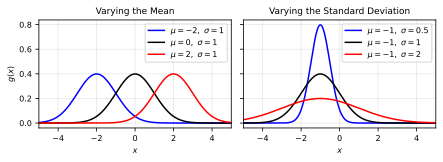

In [11]:
exercise_gaussian()

<a id="exercise_spiral"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 3: Generating Complex Spirals</strong>

<p style="color:#006064;">
Euler's formula describes rotation through the complex exponential, while multiplication by a positive real number changes the radius. Combining these effects produces a spiral: the angle increases repeatedly while the point gradually moves away from the origin. This exercise turns the polar representation $z=r\exp(i\gamma)$ into a small piece of generative geometry.
</p>

<p style="color:#006064;">
The function to be implemented has the form <code>generate_spiral(rad_start, rad_end, num_rot, angle_start, N)</code>. The parameters <code>rad_start</code> and <code>rad_end</code> specify the initial and final distances from the origin. The parameter <code>num_rot</code> determines the number of complete turns, <code>angle_start</code> specifies the initial direction in degrees, and <code>N</code> determines how many discrete points represent the spiral.
</p>

<ul style="color:#006064;">
<li><strong>Construct the spiral:</strong> Create <code>N</code> equally spaced rotation values from <code>0</code> to <code>num_rot</code> and radii increasing linearly from <code>rad_start</code> to <code>rad_end</code>. Convert <code>angle_start</code> from degrees to radians, and use <code>np.exp()</code> to combine the changing radius, repeated rotations, and starting angle. Return the resulting complex NumPy array.</li>

<li><strong>Visualize the result:</strong> Plot the real parts of the complex points horizontally and their imaginary parts vertically. Connect neighboring points with lines and use equal axis scaling so that the spiral is not distorted.</li>

<li><strong>Explore the parameters:</strong> Create three examples, beginning with a simple spiral and progressing to more intricate shapes by changing the radial range, number of rotations, and starting angle. Display the three spirals next to one another in a single row and include informative titles.</li>
</ul>

</div>

In [12]:
# Your Solution

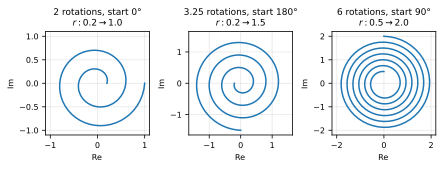

In [13]:
exercise_spiral()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>